In [20]:
# Load the dataset
import pandas as pd

df = pd.read_csv("../data/raw/customer_churn_dataset_250k.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   customer_id                250000 non-null  int64  
 1   age                        250000 non-null  int64  
 2   gender                     250000 non-null  str    
 3   region                     250000 non-null  str    
 4   contract_type              250000 non-null  str    
 5   tenure_months              250000 non-null  int64  
 6   internet_service           237432 non-null  str    
 7   monthly_charges            250000 non-null  float64
 8   data_usage_gb              250000 non-null  float64
 9   avg_call_duration_minutes  250000 non-null  float64
 10  support_calls              250000 non-null  int64  
 11  late_payments              250000 non-null  int64  
 12  payment_method             250000 non-null  str    
 13  satisfaction_score         250000 non-nu

In [ ]:
# Remove ID column
if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])

# Remove rows with missing internet_service
df = df.dropna()

df.info()

<class 'pandas.DataFrame'>
Index: 237432 entries, 0 to 249999
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        237432 non-null  int64  
 1   gender                     237432 non-null  str    
 2   region                     237432 non-null  str    
 3   contract_type              237432 non-null  str    
 4   tenure_months              237432 non-null  int64  
 5   internet_service           237432 non-null  str    
 6   monthly_charges            237432 non-null  float64
 7   data_usage_gb              237432 non-null  float64
 8   avg_call_duration_minutes  237432 non-null  float64
 9   support_calls              237432 non-null  int64  
 10  late_payments              237432 non-null  int64  
 11  payment_method             237432 non-null  str    
 12  satisfaction_score         237432 non-null  int64  
 13  churn                      237432 non-null  i

In [ ]:
# Separate features
X = df.drop("churn", axis=1)
y = df["churn"]

In [ ]:
# Encode categorical columns
cat_cols = ["gender", "region", "contract_type", "internet_service", "payment_method"]
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [28]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# Train logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [31]:
# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     32993
           1       0.74      0.70      0.72     14494

    accuracy                           0.83     47487
   macro avg       0.81      0.80      0.80     47487
weighted avg       0.83      0.83      0.83     47487

ROC-AUC: 0.9028185584950676


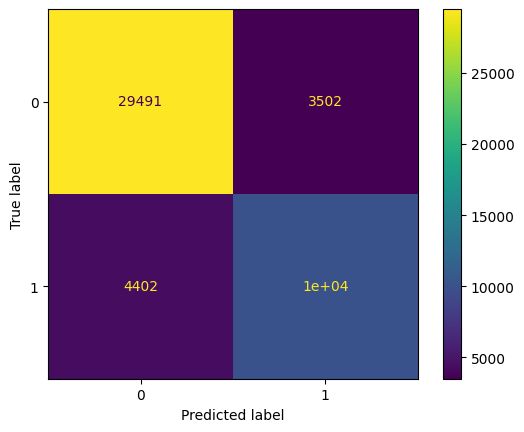

In [32]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

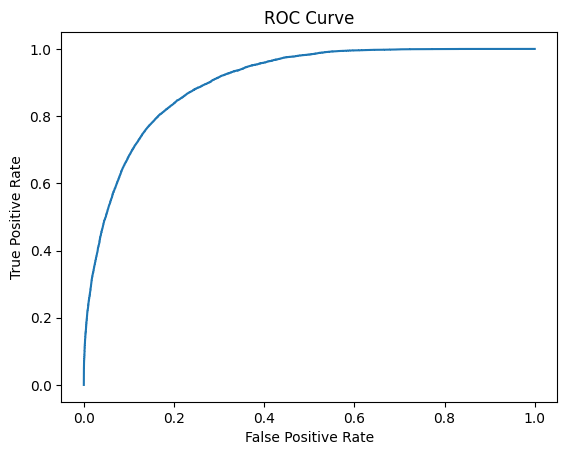

In [33]:
# ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()